In [ ]:
import mujoco
import mediapy as media
import matplotlib.pyplot as plt
import numpy as np
from robot_descriptions import panda_mj_description

HEIGHT = 480
WIDTH = 480
DURATION = 3.8  # (seconds)
FRAMERATE = 60  # (Hz)

# Panda torque limits: 87 Nm for joints 1-4, 12 Nm for joints 5-7
TORQUE_LIMITS = [87, 87, 87, 87, 12, 12, 12]

# Load the model and override arm actuators to direct torque control.
# The Panda MJCF ships with position-controlled actuators (biastype=1) that
# have built-in PD gains (e.g. Kp=4500, Kd=450), meaning ctrl is interpreted
# as a target position. For manual PD control we need ctrl = raw torque.
model = mujoco.MjModel.from_xml_path(panda_mj_description.MJCF_PATH)
for i in range(7):  # first 7 actuators = arm joints
    model.actuator_gainprm[i, 0] = 1.0      # gain * ctrl = 1 * ctrl
    model.actuator_biastype[i] = 0           # no bias term
    model.actuator_biasprm[i, :] = 0.0
    # ctrlrange was set to joint position limits (e.g. [-2.89, 2.89]) which
    # would clamp torques to ~3 Nm. Set to actual torque limits.
    model.actuator_ctrlrange[i] = [-TORQUE_LIMITS[i], TORQUE_LIMITS[i]]
    model.actuator_forcerange[i] = [-TORQUE_LIMITS[i], TORQUE_LIMITS[i]]
data = mujoco.MjData(model)

## 1.1 Theory (1–2 hours)

- [ ]  Understand PD control law: `τ = Kp * (q_desired - q) - Kd * dq`
- [ ]  Understand why derivative term provides damping (prevents oscillation)
- [ ]  Learn about critical damping: `Kd = 2 * sqrt(Kp)` as a starting heuristic
- [ ]  Understand gravity compensation: why you need to add `qfrc_bias` to your torques

## PD Control Law

The PD control law: τ = Kp * (q_des - q) - Kd * dq

**PD = proportional derivative**, the two terms in PD control law.

**Proportional**: Torque propotional to position *error* (how far from target)
**Derivative**: Torque proportional to velocity


`Kp * (q_des - q)` is proprtional term. Same as Hooke's law. The further the joint it away from the target the harder it pulls. Kp is the spring stiffness.

`-Kd * dq` is the derivative term. Acts as a damper. It produces torque that opposed motion. Without it the proportional term would overshoot the target, swing back, overshoot again, and oscillate like an undamped spring. The damper bleeds the energy out of the system.


Critical damping: Kd = 2 * sqrt(Kp)
This comes from the second-order system analogy. A mass-spring-damper system has three regimes:

Underdamped (Kd too low): oscillates around the target before settling
Overdamped (Kd too high): sluggishly creeps toward the target, no overshoot but slow
Critically damped (Kd = 2 * sqrt(Kp * m) for a unit mass): fastest convergence without oscillation

In practice Kd = 2 * sqrt(Kp) is a starting point because it assumes unit effective inertia at each joint, which is wrong — the effective inertia changes with configuration. But it gets you in the right ballpark and you tune from there.

""

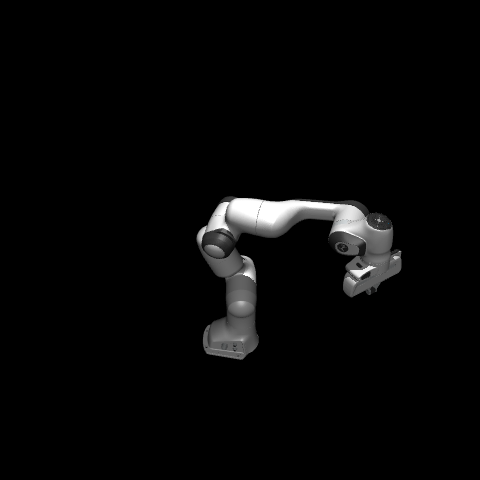

In [34]:
mujoco.mj_resetData(model, data)
DESIRED_QPOS = [0, -0.4, -0.35, -1.92, -0.15, 1.63, 1.5]  # arm joints
data.qpos = DESIRED_QPOS + [0, 0]  # plus gripper joints

with mujoco.Renderer(model, HEIGHT, WIDTH) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

### Proportional term (spring)

In [35]:
q_des = np.array(DESIRED_QPOS)
q_des

array([ 0.  , -0.4 , -0.35, -1.92, -0.15,  1.63,  1.5 ])

In [36]:
q = np.array(data.qpos)[:7]
q

array([ 0.  , -0.4 , -0.35, -1.92, -0.15,  1.63,  1.5 ])

In [37]:
q_des - q

array([0., 0., 0., 0., 0., 0., 0.])

In [38]:
Kp = 500.0
tau = Kp * (q_des - q)
tau

array([0., 0., 0., 0., 0., 0., 0.])

In [39]:
frames = []
mujoco.mj_resetData(model, data)
with mujoco.Renderer(model) as renderer:
  while data.time < DURATION:
    q = np.array(data.qpos)
    data.ctrl[:7] = Kp * (q_des - q[:7])
    mujoco.mj_step(model, data)

    if len(frames) < data.time * FRAMERATE:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=FRAMERATE)

This browser does not support the video tag.


In [40]:
videos = {}
histories = {}  # Kp -> {"time": [...], "qpos": [...]}

for Kp in (5, 20, 50, 100, 200, 500):
    frames = []
    times = []
    qpos_log = []

    mujoco.mj_resetData(model, data)
    with mujoco.Renderer(model) as renderer:
        while data.time < DURATION:
            q = np.array(data.qpos[:7])
            data.ctrl[:7] = Kp * (q_des - q)
            mujoco.mj_step(model, data)

            times.append(data.time)
            qpos_log.append(q.copy())

            if len(frames) < data.time * FRAMERATE:
                renderer.update_scene(data)
                frames.append(renderer.render())

    videos[f"Kp={Kp}"] = frames
    histories[f"Kp={Kp}"] = {"time": np.array(times), "qpos": np.array(qpos_log)}

media.show_videos(videos, fps=FRAMERATE, columns=3)

Kp=5 This browser does not support the video tag.,Kp=20 This browser does not support the video tag.,Kp=50 This browser does not support the video tag.
Kp=100 This browser does not support the video tag.,Kp=200 This browser does not support the video tag.,Kp=500 This browser does not support the video tag.


- Too low Kp -> doesn't reach the desired pose, or very slow  
- Too high Kp -> Fast but oscillation / unstability

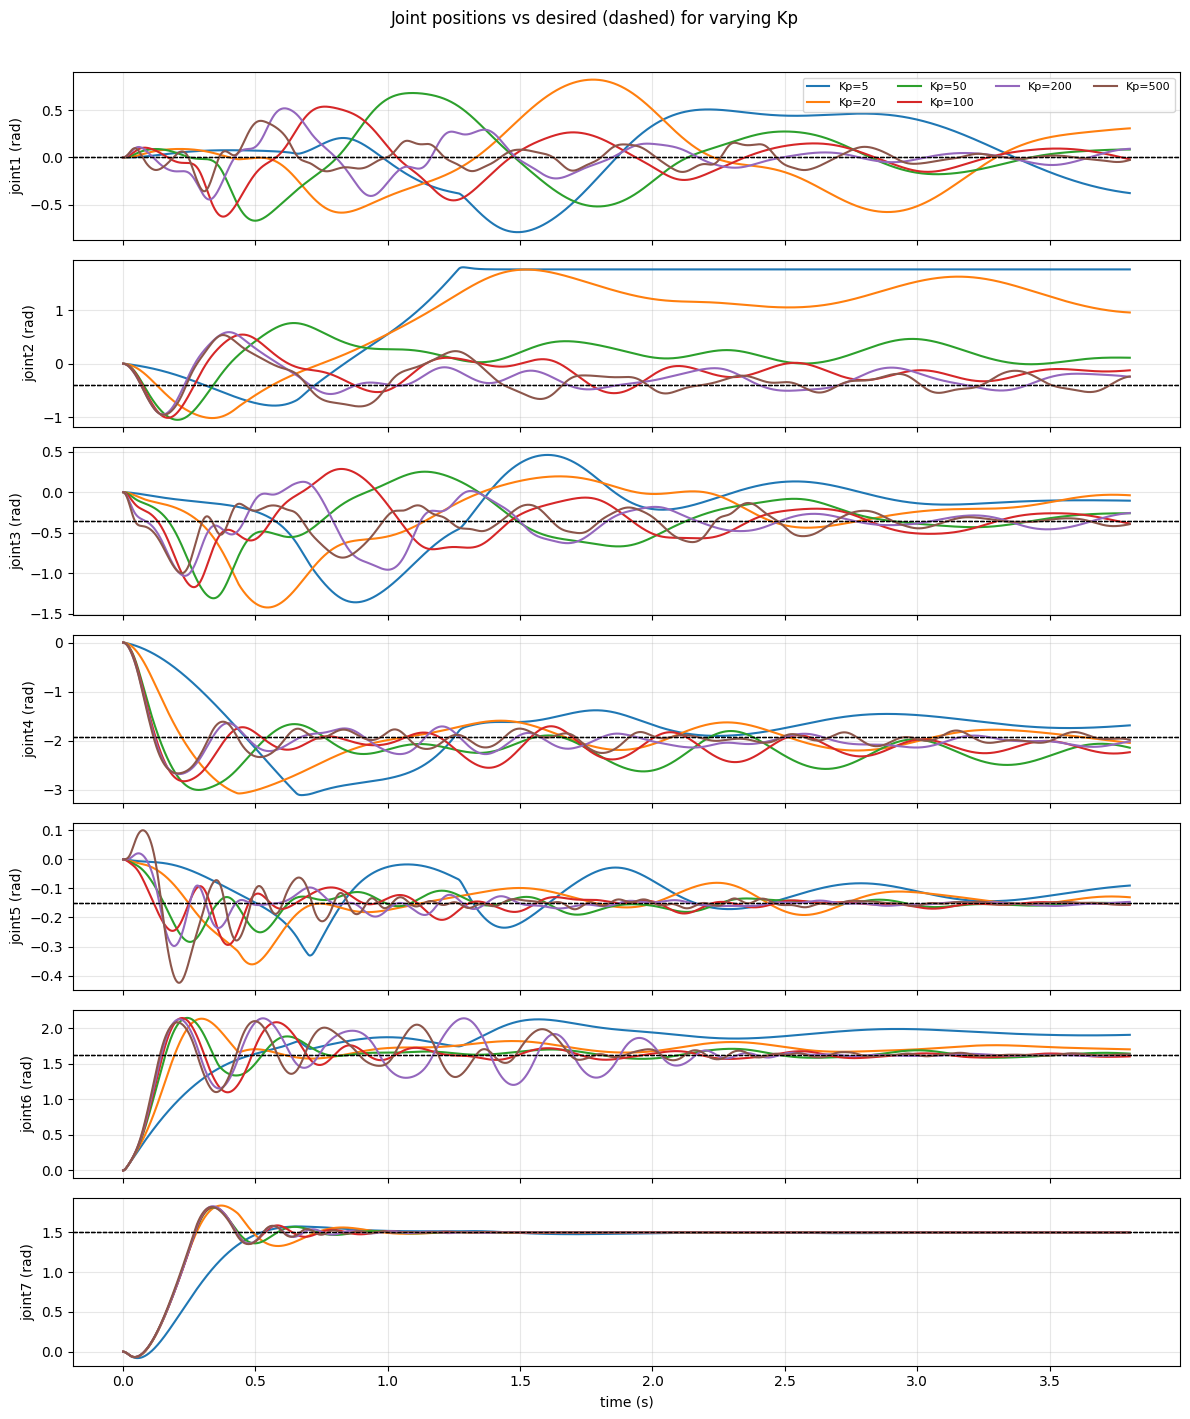

In [41]:
fig, axes = plt.subplots(7, 1, figsize=(12, 14), sharex=True)

for label, h in histories.items():
    t = h["time"]
    for j, ax in enumerate(axes):
        ax.plot(t, h["qpos"][:, j], label=label)
        ax.axhline(q_des[j], color="k", linestyle="--", linewidth=0.8)
        ax.set_ylabel(f"joint{j+1} (rad)")
        ax.grid(True, alpha=0.3)

axes[0].legend(loc="upper right", ncol=4, fontsize=8)
axes[-1].set_xlabel("time (s)")
fig.suptitle("Joint positions vs desired (dashed) for varying Kp", y=1.01)
plt.tight_layout()
plt.show()

Each joint has different effective inertia (e.g. joint 1 moves whole arm, joint 7 just moves EE).  
So different Kp is used for each joint

### Adding Derivative Term

In [42]:
Kp = 100

# Use mass-matrix-aware Kd for critical damping: Kd = 2 * sqrt(Kp * M_ii)
mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)
M = np.zeros((model.nv, model.nv))
mujoco.mj_fullM(model, M, data.qM)
Kd = 2 * np.sqrt(Kp * np.diag(M)[:7])

videos = {}
histories = {}

for label, kd in {"No Kd (P only)": np.zeros(7), f"With Kd (PD)": Kd}.items():
    frames = []

    times = []
    qpos_log = []
    
    mujoco.mj_resetData(model, data)
    with mujoco.Renderer(model) as renderer:
        while data.time < DURATION:
            q = np.array(data.qpos)[:7]
            dq = np.array(data.qvel)[:7]
            data.ctrl[:7] = Kp * (q_des - q) - kd * dq
            mujoco.mj_step(model, data)

            times.append(data.time)
            qpos_log.append(q.copy())

            if len(frames) < data.time * FRAMERATE:
                renderer.update_scene(data)
                frames.append(renderer.render())

    videos[label] = frames
    histories[label] = {"time": np.array(times), "qpos": np.array(qpos_log)}

media.show_videos(videos, fps=FRAMERATE)

No Kd (P only) This browser does not support the video tag.,With Kd (PD) This browser does not support the video tag.


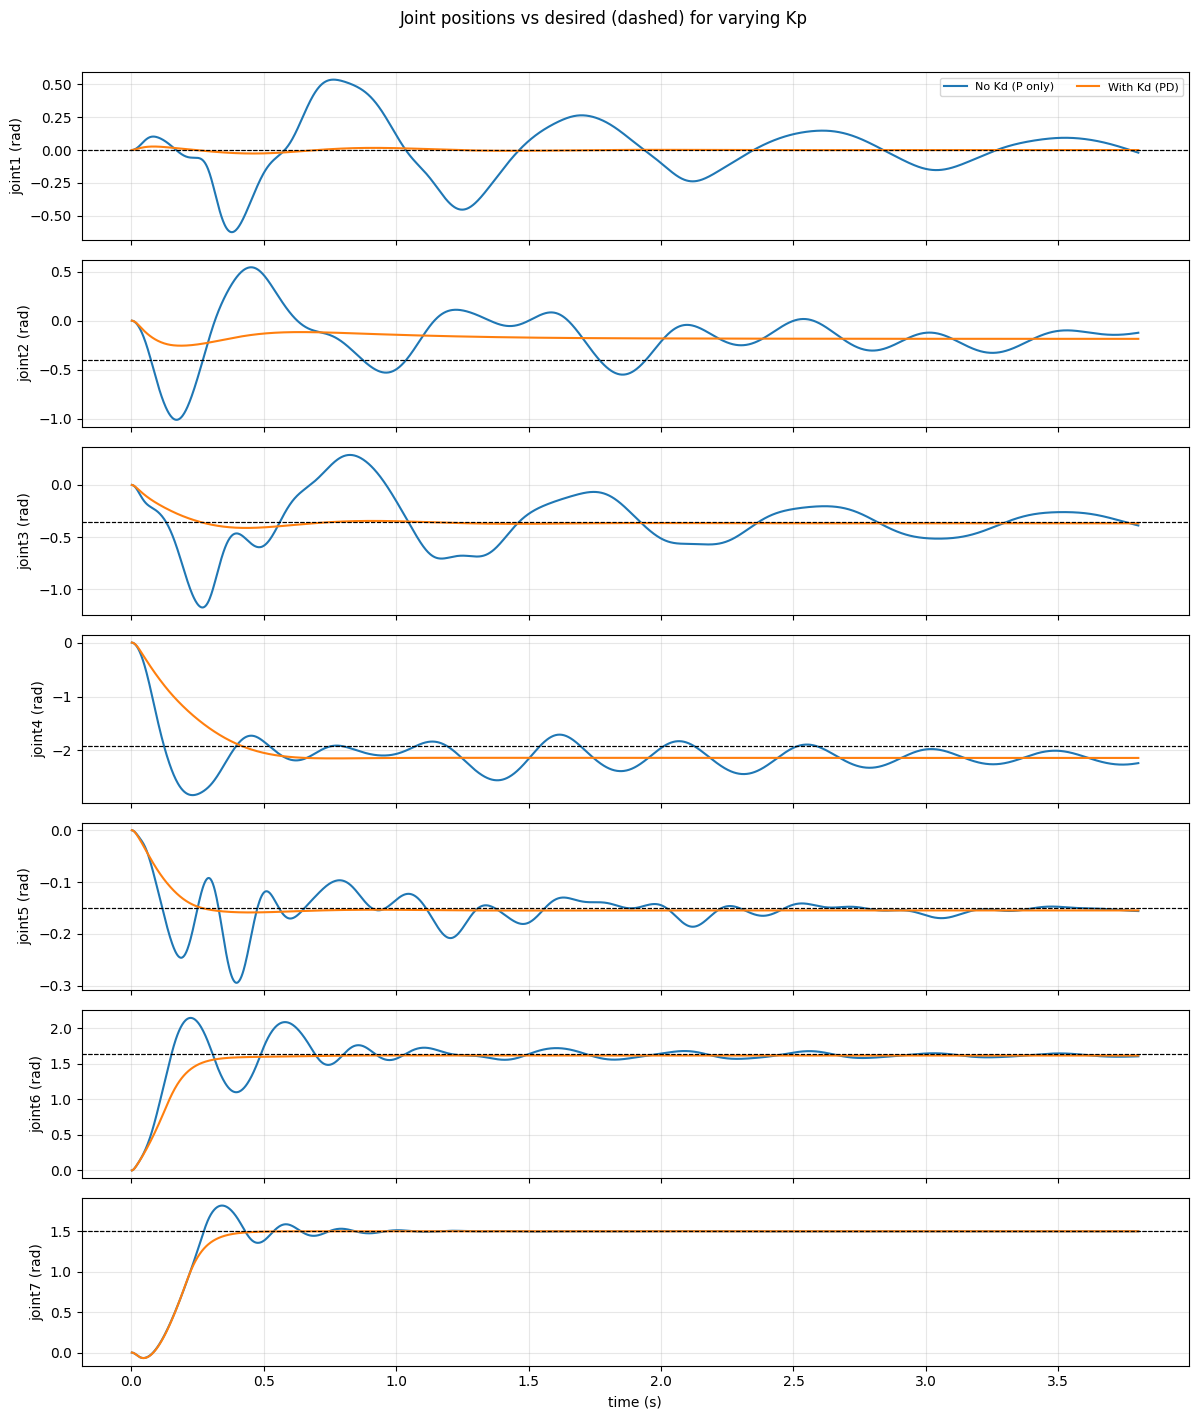

In [43]:
fig, axes = plt.subplots(7, 1, figsize=(12, 14), sharex=True)

for label, h in histories.items():
    t = h["time"]
    for j, ax in enumerate(axes):
        ax.plot(t, h["qpos"][:, j], label=label)
        ax.axhline(q_des[j], color="k", linestyle="--", linewidth=0.8)
        ax.set_ylabel(f"joint{j+1} (rad)")
        ax.grid(True, alpha=0.3)

axes[0].legend(loc="upper right", ncol=4, fontsize=8)
axes[-1].set_xlabel("time (s)")
fig.suptitle("Joint positions vs desired (dashed) for varying Kp", y=1.01)
plt.tight_layout()
plt.show()

<cell_type>markdown</cell_type>### Gravity Compensation
If we reach `q_des = q` then `tau = 0` so no torque is being applied, but gravity is pulling the arm down.


To fix this we need to add torque to conteract gravity 

```
τ = Kp * (q_des - q) - Kd * dq + τ_gravity
```


MuJoCo has `data.qfrc_bias` containing gravity forces and coriolis/centrifugal forces.

In [44]:
print(model.opt.gravity)

[ 0.    0.   -9.81]


In [49]:
Kp = 100

Kd = 2 * np.sqrt(Kp)

configs = {
    "PD only": False,
    "PD + gravity comp": True,
}

videos = {}
histories = {}

for label, use_gravity_comp in configs.items():
    frames = []
    times, qs = [], []
    mujoco.mj_resetData(model, data)
    with mujoco.Renderer(model) as renderer:
        while data.time < DURATION:
            q = np.array(data.qpos)[:7]
            dq = np.array(data.qvel)[:7]
            grav = data.qfrc_bias[:7] if use_gravity_comp else 0
            data.ctrl[:7] = Kp * (q_des - q) - Kd * dq + grav
            mujoco.mj_step(model, data)

            times.append(data.time)
            qs.append(data.qpos[:7].copy())

            if len(frames) < data.time * FRAMERATE:
                renderer.update_scene(data)
                frames.append(renderer.render())

    videos[label] = frames
    histories[label] = (times, np.array(qs))

media.show_videos(videos, fps=FRAMERATE)

PD only This browser does not support the video tag.,PD + gravity comp This browser does not support the video tag.


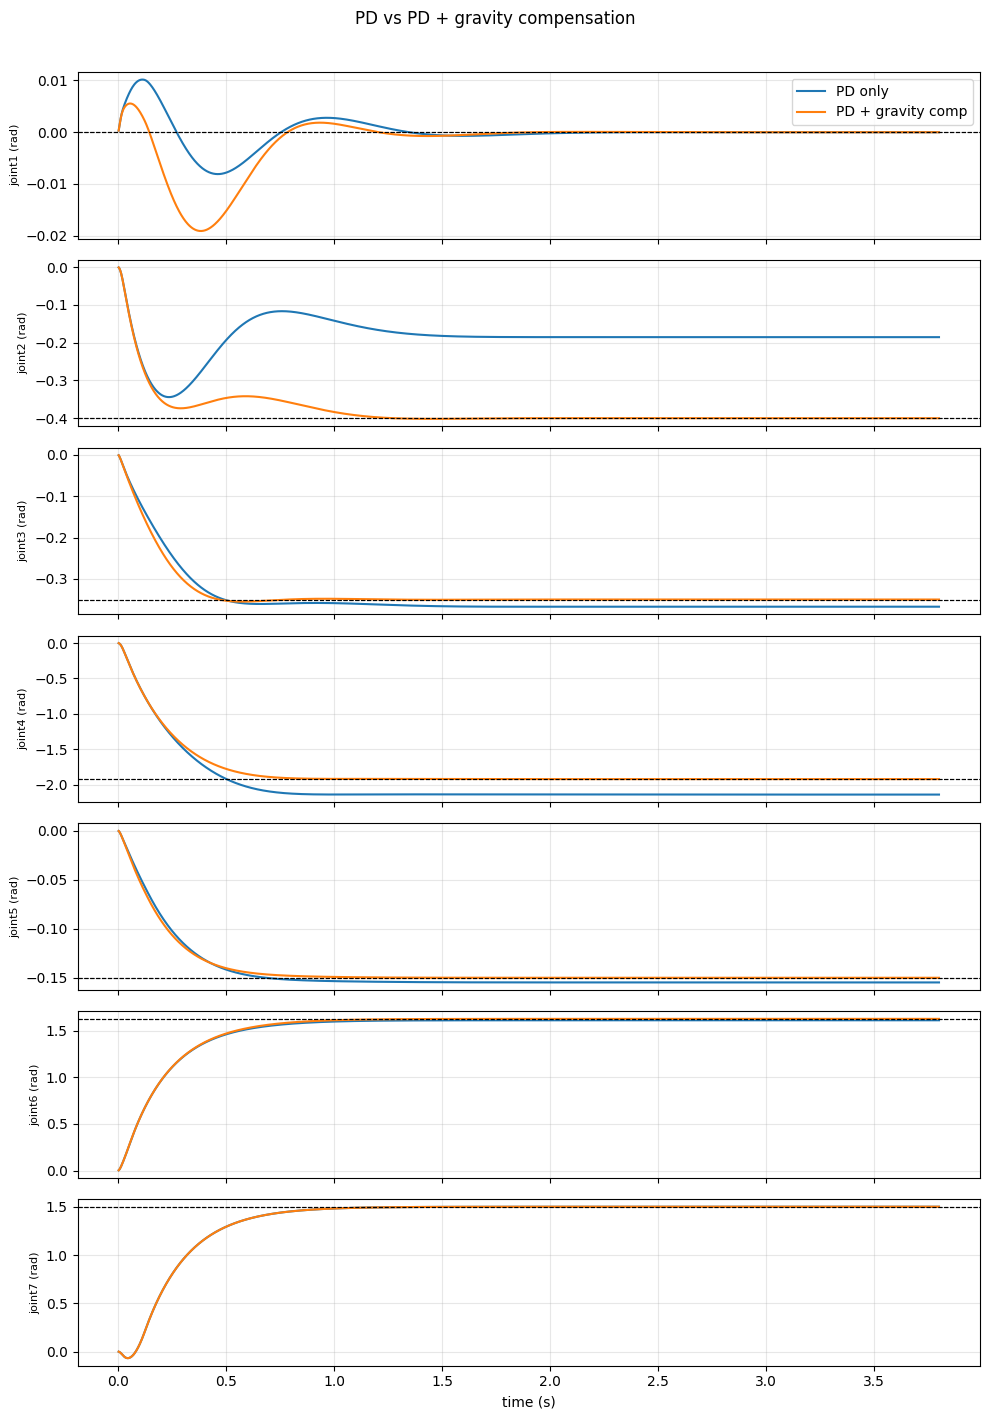

In [50]:
fig, axes = plt.subplots(7, 1, figsize=(10, 14), sharex=True)

for label, (times, qpos) in histories.items():
    for j, ax in enumerate(axes):
        ax.plot(times, qpos[:, j], label=label)
        ax.axhline(q_des[j], color="k", linestyle="--", linewidth=0.8)
        ax.set_ylabel(f"joint{j+1} (rad)", fontsize=8)
        ax.grid(True, alpha=0.3)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("time (s)")
fig.suptitle("PD vs PD + gravity compensation", y=1.01)
plt.tight_layout()
plt.show()

In [62]:
Kp = 300
Kd = 2 * np.sqrt(Kp)

videos = {}
CONFIGS = {
    "home":        [0, 0, 0, -1.57, 0, 1.57, 0],
    "candle":      [0, 0, 0, -0.07, 0, 0.05, 0],
    "ready":       [0, -0.78, 0, -2.36, 0, 1.57, 0.78],
    "left_reach":  [1.0, -0.5, 0.5, -1.8, -0.3, 1.5, 0.5],
    "right_reach": [-1.0, -0.5, -0.5, -1.8, 0.3, 1.5, -0.5],
    "tucked":      [0, -1.2, 0, -2.8, 0, 3.5, 0],
    "stretched":   [0, 0.5, 0, -0.5, 0, 1.0, 0],
}

for label, q_des in CONFIGS.items():
    frames = []
    mujoco.mj_resetData(model, data)
    with mujoco.Renderer(model) as renderer:
        while data.time < DURATION:
            q = np.array(data.qpos)[:7]
            dq = np.array(data.qvel)[:7]
            grav = data.qfrc_bias[:7] if use_gravity_comp else 0
            data.ctrl[:7] = Kp * (q_des - q) - Kd * dq + grav
            mujoco.mj_step(model, data)

            if len(frames) < data.time * FRAMERATE:
                renderer.update_scene(data)
                frames.append(renderer.render())

    videos[label] = frames

media.show_videos(videos, fps=FRAMERATE, columns=4)